# Phép chập rời rạc (discrete-time convolution)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/<USER>/<REPO>/blob/main/notebooks/00_phep-chap-roi-rac.ipynb)

Notebook minh họa cách tính tổng chập (convolution sum) của hệ thống tuyến tính bất biến theo thời gian (LTI) rời rạc theo các bước *lấy đối xứng – dịch – nhân – cộng*.

**Mục tiêu**
- Thấy rằng đầu ra của hệ thống LTI rời rạc được xác định hoàn toàn bởi đáp ứng xung (impulse response) $h[n]$ thông qua tổng chập.
- Thực hiện tổng chập theo từng bước: lấy đối xứng, dịch, nhân, cộng.
- Xác định độ dài và chỉ số bắt đầu của tín hiệu ra.
- Kiểm chứng tính giao hoán và quan sát tác dụng làm mượt của bộ lọc trung bình trượt (moving average).

## Tóm tắt lý thuyết

Với hệ thống LTI rời rạc có đáp ứng xung $h[n]$, tín hiệu ra ứng với tín hiệu vào $x[n]$ là

$$
y[n] = x[n] * h[n] := \sum_{k=-\infty}^{\infty} x[k]\,h[n-k].
$$

Với mỗi giá trị $n$ cố định, $y[n]$ được tính qua bốn bước trên trục biến $k$:

1. **Lấy đối xứng** (đảo trục thời gian) $h[k]$ qua gốc để được $h[-k]$;
2. **Dịch** sang phải $n$ mẫu để được $h[n-k]$;
3. **Nhân** từng mẫu với $x[k]$;
4. **Cộng** các tích theo $k$.

Nếu $x[n]$ khác 0 trên $n_x \le n \le n_x + N_x - 1$ và $h[n]$ khác 0 trên $n_h \le n \le n_h + N_h - 1$ thì $y[n]$ chỉ có thể khác 0 trên

$$
n_x + n_h \;\le\; n \;\le\; n_x + n_h + N_x + N_h - 2,
$$

tức là có độ dài $N_x + N_h - 1$ mẫu.

*Xem thêm: Giáo trình, Chương 2 (Hệ thống LTI).*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

def stem(ax, n, x, color="C0", label=None, hollow=False):
    """Vẽ tín hiệu rời rạc x[n] dạng stem; hollow=True dùng marker rỗng."""
    m, s, b = ax.stem(n, x, linefmt=color + "-", markerfmt=color + "o",
                      basefmt="k-", label=label)
    plt.setp(s, linewidth=1.5)
    plt.setp(m, markersize=6)
    plt.setp(b, linewidth=0.8)
    if hollow:
        m.set_markerfacecolor("none")
    ax.set_xlabel("$n$")
    return ax

def conv_idx(x, nx0, h, nh0):
    """Phép chập kèm trục chỉ số; nx0, nh0 là chỉ số của mẫu đầu tiên."""
    y = np.convolve(x, h)
    ny = np.arange(len(y)) + nx0 + nh0
    return ny, y

## 1. Tín hiệu vào và đáp ứng xung

Xét tín hiệu vào là dãy xung chữ nhật 5 mẫu, khác 0 với $-2 \le n \le 2$:
$$x[n] = \operatorname{rect}_5[n+2] = u[n+2] - u[n-3],$$
và hệ có đáp ứng xung hữu hạn 6 mẫu:
$$h[n] = \alpha^n \operatorname{rect}_6[n], \qquad \alpha = 0{,}7,$$
trong đó dãy chữ nhật $\operatorname{rect}_N[n]$ bằng 1 khi $0 \le n \le N-1$ và bằng 0 ở ngoài khoảng đó.

Lưu ý $x[n]$ **không** bắt đầu tại $n=0$: ta luôn lưu kèm mảng chỉ số `nx`, `nh` với mảng giá trị.

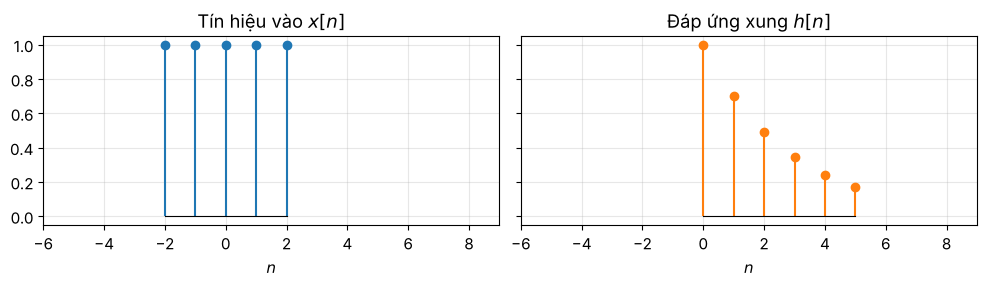

In [2]:
# Tín hiệu vào: dãy xung chữ nhật, khác 0 khi -2 <= n <= 2
nx = np.arange(-2, 3)
x = np.ones(len(nx))

# Đáp ứng xung: h[n] = alpha^n rect_6[n] (khác 0 khi 0 <= n <= 5), alpha = 0.7
nh = np.arange(0, 6)
alpha = 0.7
h = alpha ** nh

fig, axs = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
stem(axs[0], nx, x)
axs[0].set_title("Tín hiệu vào $x[n]$")
stem(axs[1], nh, h, color="C1")
axs[1].set_title("Đáp ứng xung $h[n]$")
for ax in axs:
    ax.set_xlim(-6, 9)
plt.tight_layout()
plt.show()

## 2. Lấy đối xứng – dịch – nhân – cộng

Hình dưới minh họa cách tính $y[n]$ tại ba giá trị $n = -3,\ 1,\ 4$.
- **Hàng trên:** $x[k]$ (xanh, marker đặc) và $h[n-k]$ (cam, marker rỗng) vẽ trên cùng trục $k$.
- **Hàng dưới:** tích $x[k]\,h[n-k]$. Tổng các mẫu ở hàng dưới chính là $y[n]$.

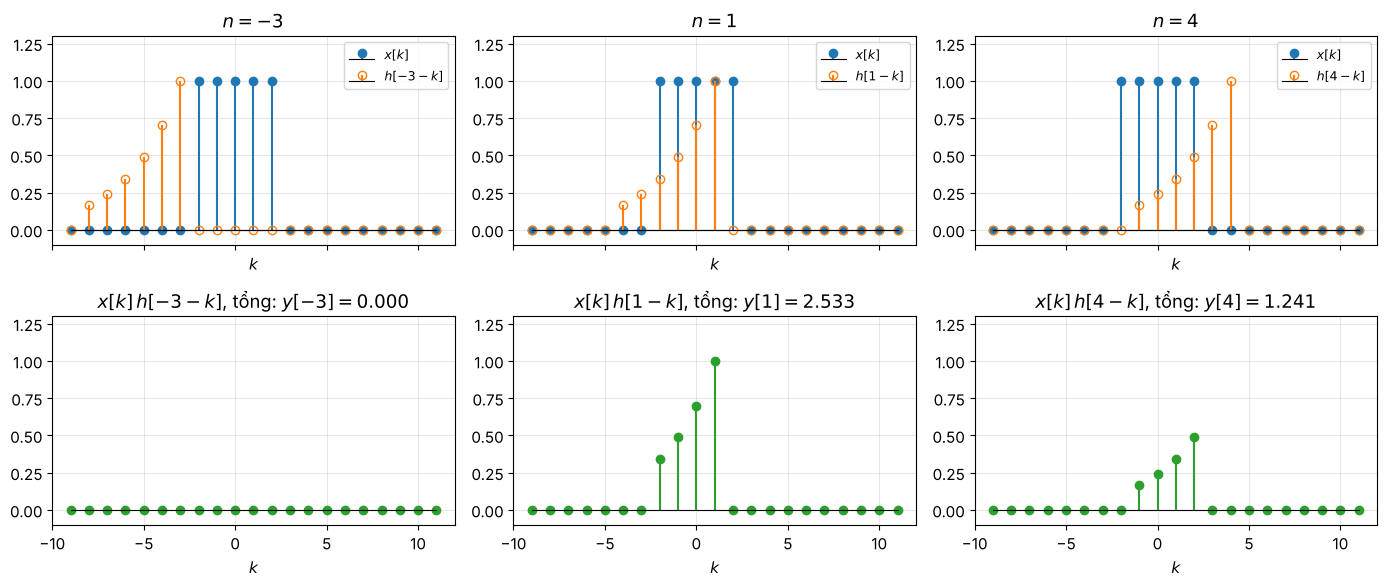

In [3]:
k = np.arange(-9, 12)   # trục k đủ rộng để chứa mọi vị trí cần xem

def tren_truc(nv, v, k):
    """Đặt tín hiệu (chỉ số nv, giá trị v) lên trục k; ngoài miền xác định bằng 0."""
    out = np.zeros(len(k))
    for ni, vi in zip(nv, v):
        out[k == ni] = vi
    return out

xk = tren_truc(nx, x, k)

def h_lat_dich(n):
    """Trả về h[n-k] trên trục k: mẫu h[m] nằm tại vị trí k = n - m."""
    return tren_truc(n - nh, h, k)

def ve_buoc(n, ax_tren, ax_duoi):
    hk = h_lat_dich(n)
    tich = xk * hk
    stem(ax_tren, k, xk, color="C0", label="$x[k]$")
    stem(ax_tren, k, hk, color="C1", label=f"$h[{n}-k]$", hollow=True)
    ax_tren.set_title(f"$n = {n}$")
    ax_tren.legend(loc="upper right", fontsize=9)
    stem(ax_duoi, k, tich, color="C2")
    ax_duoi.set_title(f"$x[k]\\,h[{n}-k]$, tổng: $y[{n}] = {tich.sum():.3f}$")
    for ax in (ax_tren, ax_duoi):
        ax.set_xlabel("$k$")
        ax.set_ylim(-0.1, 1.3)

cac_n = [-3, 1, 4]
fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for j, n in enumerate(cac_n):
    ve_buoc(n, axs[0, j], axs[1, j])
plt.tight_layout()
plt.show()

**Nhận xét.**
- Tại $n=-3$, $h[-3-k]$ chưa chồng lấp với vùng $x[k] \neq 0$ nên $y[-3] = 0$.
- Tại $n=1$, bốn mẫu $h[0],\dots,h[3]$ chồng lấp với $x[k]$; $y[1]$ là tổng của chúng.
- Tại $n=4$, $h[n-k]$ đã trượt qua một phần, chỉ còn các mẫu nhỏ $h[2],\dots,h[5]$ chồng lấp nên $y[4]$ giảm.

Lặp lại cho mọi $n$ ta được toàn bộ $y[n]$:

Độ dài y[n]: 10  (N_x + N_h - 1 = 10 )
y[n] khác 0 với -2 <= n <= 7


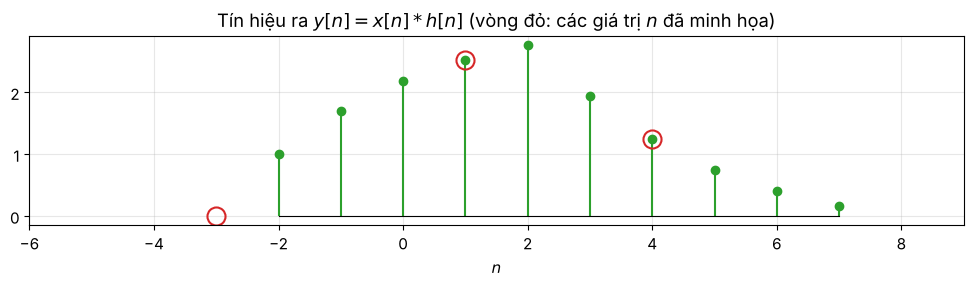

In [4]:
ny, y = conv_idx(x, nx[0], h, nh[0])

print("Độ dài y[n]:", len(y), " (N_x + N_h - 1 =", len(x) + len(h) - 1, ")")
print("y[n] khác 0 với", ny[0], "<= n <=", ny[-1])

fig, ax = plt.subplots(figsize=(10, 3))
stem(ax, ny, y, color="C2")
for n in cac_n:                                   # đánh dấu ba giá trị đã minh họa ở trên
    yn = y[ny == n][0] if n in ny else 0.0
    ax.plot(n, yn, "o", ms=13, mfc="none", mec="C3", mew=1.5)
ax.set_xlim(-6, 9)
ax.set_title("Tín hiệu ra $y[n] = x[n] * h[n]$ (vòng đỏ: các giá trị $n$ đã minh họa)")
plt.tight_layout()
plt.show()

**Nhận xét.** $y[n]$ khác 0 với $-2 \le n \le 7$, đúng bằng $n_x + n_h = -2 + 0$ đến $n_x + n_h + N_x + N_h - 2 = 7$ (10 mẫu). $y[n]$ tăng dần khi $h[n-k]$ "trượt vào" vùng $x[k] \neq 0$, đạt cực đại tại $n = 2$ — lúc năm mẫu lớn nhất $h[0],\dots,h[4]$ cùng chồng lấp với $x[k]$ — rồi giảm dần khi trượt ra.

Kiểm chứng lại kết quả của `np.convolve` bằng cách tính trực tiếp từ định nghĩa tổng chập:

In [5]:
def tong_chap_truc_tiep(nx, x, nh, h):
    """Tính y[n] = sum_k x[k] h[n-k] trực tiếp từ định nghĩa."""
    ny = np.arange(nx[0] + nh[0], nx[-1] + nh[-1] + 1)
    y = np.zeros(len(ny))
    for i, n in enumerate(ny):
        for kk, xv in zip(nx, x):
            m = n - kk                       # chỉ số của h cần dùng
            if nh[0] <= m <= nh[-1]:
                y[i] += xv * h[m - nh[0]]
    return ny, y

ny2, y2 = tong_chap_truc_tiep(nx, x, nh, h)
print("Trục chỉ số trùng khớp:", np.array_equal(ny, ny2))
print("Giá trị trùng khớp:    ", np.allclose(y, y2))
print("y[n] =", np.round(y, 4))

Trục chỉ số trùng khớp: True
Giá trị trùng khớp:     True
y[n] = [1.     1.7    2.19   2.533  2.7731 1.9412 1.2412 0.7512 0.4082 0.1681]


## 3. Khám phá tương tác

Kéo thanh trượt để thay đổi $n$ và quan sát $h[n-k]$ trượt qua $x[k]$. *(Phần này cần chạy trên Colab hoặc Jupyter; khi xem trên GitHub, hãy dùng hình tĩnh ở mục 2.)*

In [ ]:
try:
    from ipywidgets import interact, IntSlider

    def _ve(n=0):
        fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
        ve_buoc(n, axs[0], axs[1])
        plt.tight_layout()
        plt.show()

    interact(_ve, n=IntSlider(value=0, min=-5, max=10, step=1, description="n"))
except ImportError:
    print("Chưa cài ipywidgets — xem hình tĩnh ở mục 2.")

## 4. Tính giao hoán

Phép chập có tính giao hoán: $x[n] * h[n] = h[n] * x[n]$. Về mặt hệ thống, điều này có nghĩa là có thể **đổi vai trò** giữa tín hiệu vào và đáp ứng xung mà đầu ra không đổi.

In [6]:
ny_a, y_a = conv_idx(x, nx[0], h, nh[0])   # x * h
ny_b, y_b = conv_idx(h, nh[0], x, nx[0])   # h * x
print("x*h == h*x:", np.array_equal(ny_a, ny_b) and np.allclose(y_a, y_b))

x*h == h*x: True


## 5. Ứng dụng: bộ lọc trung bình trượt

Bộ lọc trung bình trượt $M$ điểm có đáp ứng xung
$$h_M[n] = \frac{1}{M}\operatorname{rect}_M[n],$$
tức là $y[n]$ bằng trung bình của $M$ mẫu gần nhất của $x[n]$. Ta áp dụng cho tín hiệu sin bị nhiễu
$$x[n] = \sin\!\left(\frac{2\pi n}{50}\right) + v[n], \qquad 0 \le n \le 199,$$
với $v[n]$ là nhiễu Gauss có độ lệch chuẩn $0{,}3$, và so sánh $M = 5$ với $M = 21$.

M =  5:  |H(e^jw0)| = 0.984,  trễ (M-1)/2 = 2 mẫu
M = 21:  |H(e^jw0)| = 0.735,  trễ (M-1)/2 = 10 mẫu


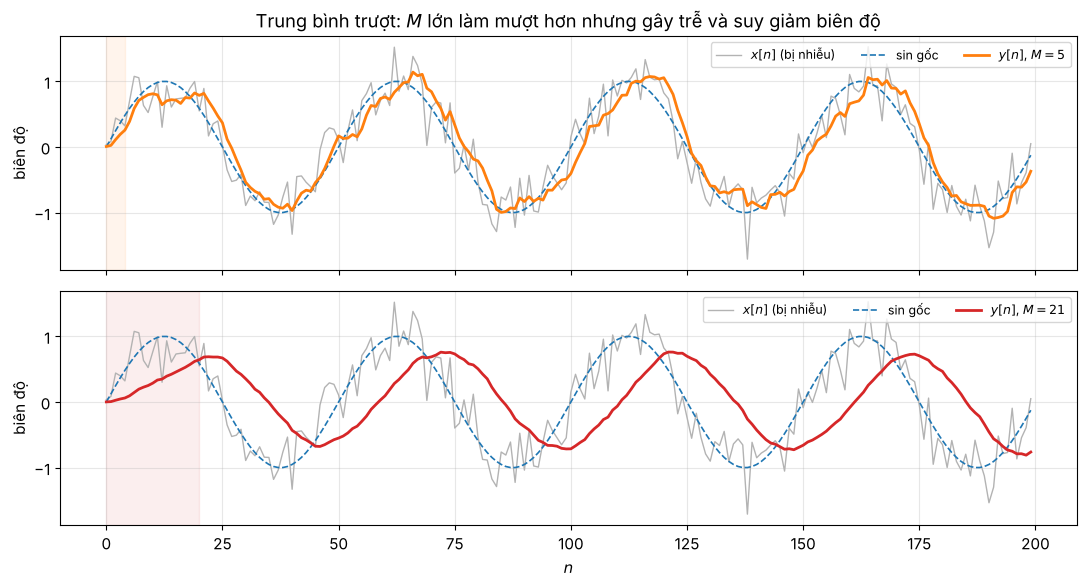

In [7]:
rng = np.random.default_rng(0)
N = 200
n = np.arange(N)
w0 = 2 * np.pi / 50                         # tần số của thành phần sin (rad/mẫu)
s = np.sin(w0 * n)                          # thành phần hữu ích
xn = s + 0.3 * rng.standard_normal(N)       # tín hiệu vào bị nhiễu

fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, M, mau in zip(axs, [5, 21], ["C1", "C3"]):
    hM = np.ones(M) / M
    yM = np.convolve(xn, hM)[:N]            # giữ N mẫu đầu: hệ nhân quả, bắt đầu từ n = 0
    ax.plot(n, xn, color="0.7", lw=1, label="$x[n]$ (bị nhiễu)")
    ax.plot(n, s, "C0--", lw=1.2, label="sin gốc")
    ax.plot(n, yM, color=mau, lw=2, label=f"$y[n]$, $M = {M}$")
    ax.axvspan(0, M - 1, color=mau, alpha=0.08)   # vùng quá độ n < M-1
    ax.set_ylabel("biên độ")
    ax.legend(loc="upper right", fontsize=9, ncol=3)
axs[1].set_xlabel("$n$")
axs[0].set_title("Trung bình trượt: $M$ lớn làm mượt hơn nhưng gây trễ và suy giảm biên độ")
plt.tight_layout()
plt.show()

# Đáp ứng biên độ |H(e^{j w0})| và độ trễ tại tần số w0
for M in [5, 21]:
    hM = np.ones(M) / M
    H = np.sum(hM * np.exp(-1j * w0 * np.arange(M)))   # H(e^{j w0})
    print(f"M = {M:2d}:  |H(e^jw0)| = {abs(H):.3f},  trễ (M-1)/2 = {(M - 1) / 2:.0f} mẫu")

**Nhận xét.**
- $M$ càng lớn, nhiễu càng được làm mượt, vì trung bình được lấy trên nhiều mẫu hơn.
- Đổi lại, tín hiệu ra **trễ** $(M-1)/2$ mẫu so với sin gốc (2 mẫu với $M=5$, 10 mẫu với $M=21$) và **biên độ giảm** (với $M=21$ còn khoảng 73% tại tần số của sin). Đây là hệ quả của đáp ứng tần số $H(e^{j\omega})$ của bộ lọc, sẽ được phân tích kỹ khi học về đáp ứng tần số.
- Vùng tô màu ở đầu là **quá độ**: với $n < M-1$, cửa sổ trung bình còn chứa các mẫu $x[n] = 0$ với $n<0$.

## Câu hỏi suy ngẫm

1. Nếu $x[n]$ khác 0 trên $[n_1, n_2]$ và $h[n]$ khác 0 trên $[n_3, n_4]$ thì $y[n]$ có thể khác 0 trên đoạn nào? Giải thích bằng hình ảnh "lấy đối xứng – dịch".
2. Tại cả $n=2$ và $n=3$, $h[n-k]$ đều chồng lấp với đủ 5 mẫu của $x[k]$. Vì sao $y[2] > y[3]$?
3. Hệ có đáp ứng xung $h[n]$ ở mục 1 có nhân quả không? Có ổn định BIBO không? Vì sao?
4. Nếu $h[n] = \delta[n - n_0]$ thì $y[n]$ bằng gì? Hệ này thực hiện phép toán gì?
5. Với bộ lọc trung bình trượt, tăng $M$ mang lại lợi ích và cái giá gì? Khi xử lý dữ liệu đã ghi sẵn (offline), có thể bù độ trễ $(M-1)/2$ mẫu bằng cách nào?